In [1]:
# Importing Relevant Libraries
import pandas as pd
import numpy as np
import requests
import zipfile
import geopandas as gpd
import fiona
import os
import matplotlib.pyplot as plt


from shapely.geometry import Point
from shapely.geometry import box
from tqdm import tqdm
from fiona.env import Env

In [2]:
# Importing stats model
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col


In [5]:
full_gdf = gpd.read_file("merged_with_flood.gpkg", layer="flood_epc_ppd")

In [3]:
# Load TE2100 policy unit shapefile, and make it fit the EPC dataset by converting to EPSG: 27700
te2100_units = gpd.read_file("Thames_Estuary_2100_Policy_Unit_Boundaries/Thames_Estuary_2100_Policy_Unit_BoundariesPolygon.shp").to_crs(epsg=27700)

In [6]:
for gdf in [full_gdf, te2100_units]:
    if 'index_right' in gdf.columns:
        gdf.drop(columns='index_right', inplace=True)


In [7]:
# Join with the te2100 units
matched_te2100 = gpd.sjoin(
    full_gdf, 
    te2100_units, 
    how='inner', 
    predicate='intersects'
)

In [8]:
# List the flood zones in the data
gdb_path = "Flood-Map-For-Planning-Flood-Zones.gdb/FMfP_Flood_Zones_v202503.gdb"
fiona.listlayers(gdb_path)

['Flood_Zones_2_3_Rivers_and_Sea']

In [9]:
flood_zones = gpd.read_file(gdb_path, layer='Flood_Zones_2_3_Rivers_and_Sea').to_crs('EPSG:27700')
#flood_zones = flood_zones.to_crs('EPSG:27700')  # Match EPC CRS 

C:\Users\HP\anaconda3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


In [10]:
fz3_gdf = flood_zones[flood_zones['flood_zone'] == 'FZ3'] # or your specific attribute

In [35]:
flood_zones.head()

,origin,flood_zone,flood_source,Shape_Length,Shape_Area,geometry
0,direct rainfall model,FZ2,river,32.0,28.0,"MULTIPOLYGON (((649792 304228, 649778 304228, ..."
1,direct rainfall model,FZ2,river,12.0,8.0,"MULTIPOLYGON (((649796 304232, 649796 304230, ..."
2,direct rainfall model,FZ2,river,8.0,4.0,"MULTIPOLYGON (((649916 304226, 649918 304226, ..."
3,direct rainfall model,FZ2,river,16.0,12.0,"MULTIPOLYGON (((649708 304212, 649714 304212, ..."
4,direct rainfall model,FZ2,river,20.0,16.0,"MULTIPOLYGON (((649726 304238, 649726 304240, ..."


In [11]:
matched_bdp = matched_te2100.copy()

In [12]:
import geopandas as gpd
from shapely.ops import nearest_points

# 1. Spatial Crop: Only keep FZ3 polygons near your properties
# Get the 'bounding box' of your matched_bdp
bbox = matched_bdp.total_bounds 

# Filter the FZ3 GDF to only those within the Estuary bounding box
fz3_estuary = fz3_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# 2. Extract Lines and Use a Spatial Index
# Exploding turns multi-polygons into simple line segments
fz3_lines = fz3_estuary.boundary.explode(index_parts=False).reset_index(drop=True)

# 3. Calculate Distance using the 'geometry' column
def calculate_precise_dist(points_gdf, lines_gdf):
    # Use spatial index to find the nearest line segment for each house
    sindex = lines_gdf.sindex
    nearest_idx = sindex.nearest(points_gdf['geometry'], return_distance=False)[1]
    
    # Measure the exact distance to that nearest segment
    distances = points_gdf['geometry'].distance(lines_gdf.iloc[nearest_idx].reset_index(drop=True))
    return distances

matched_bdp['running_var'] = calculate_precise_dist(matched_bdp, fz3_lines)

# 4. Final Re-sign: Inside FZ3 = Negative, Outside = Positive
matched_bdp.loc[matched_bdp['flood_zone'] == 'FZ3', 'running_var'] *= -1

C:\Users\HP\AppData\Local\Temp\ipykernel_23332\2397594999.py:22: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  distances = points_gdf['geometry'].distance(lines_gdf.iloc[nearest_idx].reset_index(drop=True))


In [13]:
matched_bdp.to_file(
    "matched_bdp_analysis_ready.gpkg",
    layer="matched_bdp",
    driver="GPKG"
)


In [3]:

matched_bdp = gpd.read_file(
    "matched_bdp_analysis_ready.gpkg",
    layer="matched_bdp"
)



In [5]:
matched_bdp.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'origin', 'flood_zon

In [6]:
matched_bdp["log_price"] = np.log(matched_bdp["Price"])

In [7]:
"HighRiskZone" in matched_bdp.columns

True

In [23]:
def run_rdd(df, bandwidth):
    df_bw = df[df["running_var"].abs() <= bandwidth].copy()
    df_bw["HighRiskZone"] = (df_bw["flood_zone"] == "FZ3").astype(int)

    model = smf.ols(
        formula="""
        log_price ~ HighRiskZone 
                  + running_var
                  + TOTAL_FLOOR_AREA
                  + NUMBER_HABITABLE_ROOMS
                  + C(PROPERTY_TYPE)
        """,
        data=df_bw
    ).fit(cov_type="HC1")

    return {
        "Bandwidth (m)": bandwidth,
        "Coef. HighRiskZone": model.params["HighRiskZone"],
        "Std. Error": model.bse["HighRiskZone"],
        "Observations": int(model.nobs),
        "R-squared": model.rsquared
    }

In [24]:
bandwidths = [50, 100, 200, 500]

table5_results = pd.DataFrame(
    [run_rdd(matched_bdp, bw) for bw in bandwidths]
)


In [25]:
import scipy.stats as stats

def add_stars(row):
    t = row["Coef. HighRiskZone"] / row["Std. Error"]
    p = 2 * (1 - stats.norm.cdf(abs(t)))
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""

table5_results["Signif."] = table5_results.apply(add_stars, axis=1)


In [26]:
table5_results["HighRiskZone Effect"] = (
    table5_results["Coef. HighRiskZone"].round(3).astype(str)
    + table5_results["Signif."]
    + " (" + table5_results["Std. Error"].round(3).astype(str) + ")"
)

table5_final = table5_results[[
    "Bandwidth (m)",
    "HighRiskZone Effect",
    "Observations",
    "R-squared"
]]


In [28]:
table5_final

,Bandwidth (m),HighRiskZone Effect,Observations,R-squared
0,50,-0.113 (0.144),174,0.334427
1,100,0.03 (0.099),304,0.347666
2,200,0.003 (0.07),532,0.326537
3,500,0.062 (0.048),1036,0.306347


In [9]:
matched_bdp['Date_of_Transfer'] = pd.to_datetime(matched_bdp['Date of Transfer'])
matched_bdp['year'] = matched_bdp['Date_of_Transfer'].dt.year
matched_bdp['quarter'] = matched_bdp['Date_of_Transfer'].dt.to_period('Q').astype(str)

In [11]:
matched_bdp.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'origin', 'flood_zon

In [12]:
print("Hello World!!!")

Hello World!!!


In [41]:

# Extract year from year_quarter_fe
#matched_bdp["year_fe"] = matched_bdp["quarter"].str[:4].astype(int)

# Event time relative to TE2100 (2013)
matched_bdp["event_time"] = matched_bdp["year"] - 2013

# Cap leads/lags (standard)
matched_bdp["event_time"] = matched_bdp["event_time"].clip(-5, 5)


In [42]:
# This is for identification
es_df = matched_bdp[matched_bdp["event_time"] != -1].copy()
es_df["event_time"] = es_df["event_time"].astype(int)


In [38]:
es_df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'origin', 'flood_zon

In [50]:
es_df["quarter"] = es_df["quarter"].astype(str)

In [57]:
event_formula = """
log_price ~ C(event_time)*HighRiskZone
           + TOTAL_FLOOR_AREA
           + NUMBER_HABITABLE_ROOMS
           + C(PROPERTY_TYPE)
           + C(pmu)
           + C(quarter)
"""

In [56]:
# --- Step 1: Pre-clean specifically for these columns ---
model_vars = ['log_price', 'event_time', 'HighRiskZone', 'TOTAL_FLOOR_AREA', 
              'NUMBER_HABITABLE_ROOMS', 'PROPERTY_TYPE', 'pmu', 'quarter']

# Create a clean copy with no missing values in these columns
es_df_final = es_df.dropna(subset=model_vars).copy()

# --- Step 2: Define the model ---
import statsmodels.formula.api as smf

event_model_obj = smf.ols(formula=event_formula, data=es_df_final)

# --- Step 3: Fit with explicit index-matched groups ---
# Using the index of the cleaned dataframe ensures 'groups' matches the observations exactly
event_model = event_model_obj.fit(
    cov_type="cluster",
    cov_kwds={"groups": es_df_final["pmu"]}
)

print(event_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                -3.531e+14
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               1.00
Time:                        01:12:18   Log-Likelihood:                -15273.
No. Observations:               62423   AIC:                         3.071e+04
Df Residuals:                   62340   BIC:                         3.146e+04
Df Model:                          82                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 101, but rank is 16
  warnings.warn('covariance of constraints does not have full '


In [15]:


# 1. Define the event time (e.g., relative to 2013 policy change)
matched_bdp['event_time'] = matched_bdp['year'] - 2013

# 2. Select variables and drop NaNs to ensure cluster group alignment
model_vars = ['log_price', 'event_time', 'HighRiskZone', 'TOTAL_FLOOR_AREA', 
              'NUMBER_HABITABLE_ROOMS', 'PROPERTY_TYPE', 'pmu', 'quarter']

es_df = matched_bdp.dropna(subset=model_vars).copy()

# 3. Define and Fit the Model
# We treat event_time as a Category to get lead/lag coefficients
event_formula = """
log_price ~ C(event_time, Treatment(reference=-1))*HighRiskZone 
            + TOTAL_FLOOR_AREA 
            + NUMBER_HABITABLE_ROOMS 
            + C(PROPERTY_TYPE) 
            + C(pmu) 
            + C(quarter)
"""

event_model = smf.ols(formula=event_formula, data=es_df).fit(
    cov_type="cluster", 
    cov_kwds={"groups": es_df["pmu"]}
)

In [24]:
# Check if HighRiskZone exists in the main dataset vs the cleaned model dataset
print(f"Total 'True' in matched_bdp: {matched_bdp['HighRiskZone'].sum()}")
print(f"Total 'True' in es_df (before dropna): {es_df['HighRiskZone'].sum()}")

# Identify which column is causing the most 'True' rows to be dropped
cols_to_check = ['TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'pmu', 'quarter']
for col in cols_to_check:
    missing_treated = matched_bdp[matched_bdp['HighRiskZone'] == True][col].isna().sum()
    print(f"Treated rows missing '{col}': {missing_treated}")

Total 'True' in matched_bdp: 0
Total 'True' in es_df (before dropna): 0
Treated rows missing 'TOTAL_FLOOR_AREA': 0
Treated rows missing 'NUMBER_HABITABLE_ROOMS': 0
Treated rows missing 'pmu': 0
Treated rows missing 'quarter': 0


In [21]:
rows = []

# Using the list you just provided
all_terms = event_model.params.index.tolist()

for term in all_terms:
    # Target the interaction terms specifically
    if "C(event_time" in term and "HighRiskZone[T.True]" in term:
        try:
            # Extract the year: find the part between [T. and ] 
            # Example: 'C(event_time...)[T.-5]:HighRiskZone[T.True]' -> '-5'
            start = term.find(")[T.") + 4
            end = term.find("]", start)
            year_str = term[start:end]
            
            k = int(year_str)
            
            rows.append({
                "Event time (years)": k,
                "Coefficient": event_model.params[term],
                "Std. Error": event_model.bse[term],
                "p-value": event_model.pvalues[term],
                "Conf. Low": event_model.conf_int().loc[term, 0],
                "Conf. High": event_model.conf_int().loc[term, 1]
            })
        except Exception as e:
            continue

# Add the reference period (Year -1) manually so it shows up as 0 on your plot
rows.append({
    "Event time (years)": -1,
    "Coefficient": 0.0,
    "Std. Error": 0.0,
    "p-value": 1.0,
    "Conf. Low": 0.0,
    "Conf. High": 0.0
})

table6 = pd.DataFrame(rows).sort_values("Event time (years)").reset_index(drop=True)

print("Table 6 Created Successfully")
print(table6)

Table 6 Created Successfully
    Event time (years)  Coefficient  Std. Error  p-value  Conf. Low  \
0                   -5          0.0         0.0      NaN        0.0   
1                   -4          0.0         0.0      NaN        0.0   
2                   -3          0.0         0.0      NaN        0.0   
3                   -2          0.0         0.0      NaN        0.0   
4                   -1          0.0         0.0      1.0        0.0   
5                    0          0.0         0.0      NaN        0.0   
6                    1          0.0         0.0      NaN        0.0   
7                    2          0.0         0.0      NaN        0.0   
8                    3          0.0         0.0      NaN        0.0   
9                    4          0.0         0.0      NaN        0.0   
10                   5          0.0         0.0      NaN        0.0   
11                   6          0.0         0.0      NaN        0.0   
12                   7          0.0         0.0 

In [20]:
matched_bdp["HighRiskZone"].dtype

dtype('bool')

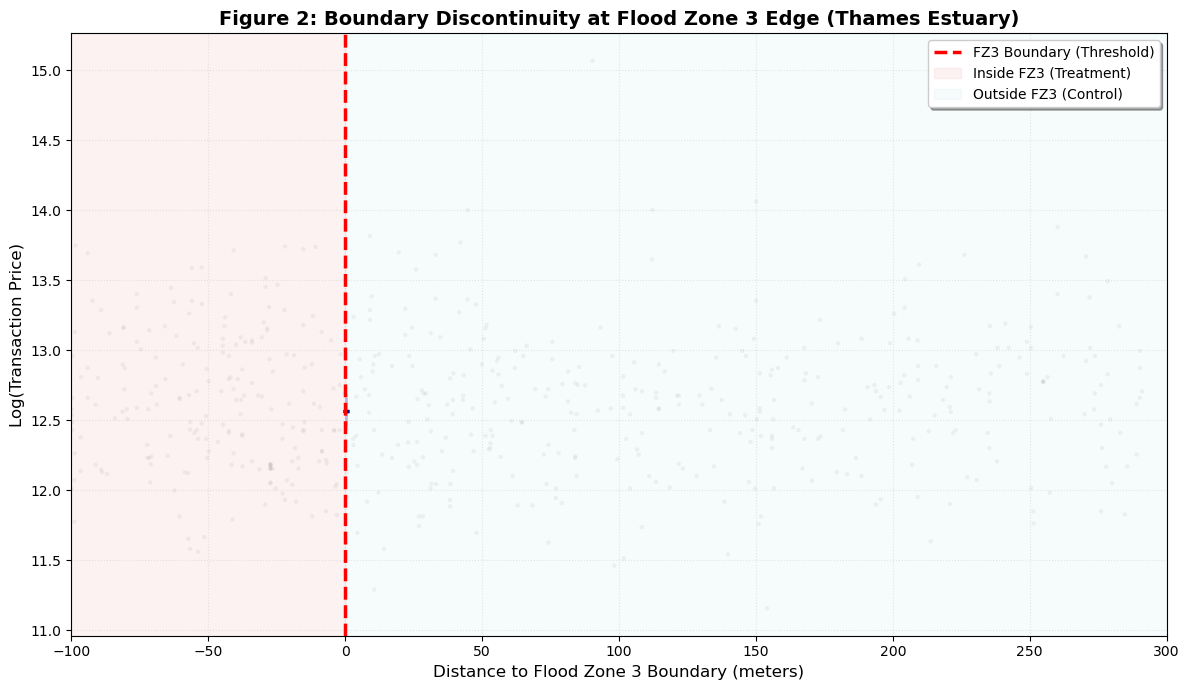

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Step 1: Ensure log price exists ---
if 'log_price' not in matched_te2100.columns:
    matched_bdp['log_price'] = np.log(matched_bdp['Price'])
    
# --- Step 1: Filter for the Thames Estuary Bandwidth ---
# We focus on properties within 100m inside and 300m outside for the best visual clarity
bandwidth_df = matched_bdp[(matched_bdp['running_var'] >= -100) & 
                           (matched_bdp['running_var'] <= 300)].copy()

# --- Step 2: Initialize the Plot ---
plt.figure(figsize=(12, 7))

# Split the data to force two separate regression lines at the threshold
inside = bandwidth_df[bandwidth_df['running_var'] < 0]
outside = bandwidth_df[bandwidth_df['running_var'] >= 0]

# --- Step 3: Plot Trends and Scatter ---
# We use a linear fit (order=1) to clearly show the intercept 'jump'
if not inside.empty:
    sns.regplot(x='running_var', y='log_price', data=inside, 
                scatter=False, color='darkblue', truncate=False, 
                line_kws={'label': 'Trend: Inside FZ3'})

if not outside.empty:
    sns.regplot(x='running_var', y='log_price', data=outside, 
                scatter=False, color='darkblue', truncate=False, 
                line_kws={'label': 'Trend: Outside FZ3'})

# Scatter points with high transparency to show density without obscuring trends
plt.scatter(bandwidth_df['running_var'], bandwidth_df['log_price'], 
            s=10, alpha=0.1, color='gray', edgecolors='none')

# --- Step 4: Formatting for Journal Quality ---
# Vertical line at the treatment threshold
plt.axvline(x=0, color='red', linestyle='--', lw=2.5, label='FZ3 Boundary (Threshold)')

# Highlight the 'Treatment' and 'Control' zones
plt.axvspan(-100, 0, color='lightcoral', alpha=0.1, label='Inside FZ3 (Treatment)')
plt.axvspan(0, 300, color='lightblue', alpha=0.1, label='Outside FZ3 (Control)')

# Axis Labels and Title using your defined variables
plt.xlabel('Distance to Flood Zone 3 Boundary (meters)', fontsize=12)
plt.ylabel('Log(Transaction Price)', fontsize=12)
plt.title('Figure 2: Boundary Discontinuity at Flood Zone 3 Edge (Thames Estuary)', 
          fontsize=14, fontweight='bold')

# Refine legend and grid
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle=':')
plt.xlim(-100, 300)
plt.tight_layout()

# Save for your report
plt.savefig("Figure2_Boundary_Discontinuity_Reinvented.png", dpi=300)
plt.show()

In [15]:
matched_bdp.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'origin', 'flood_zon

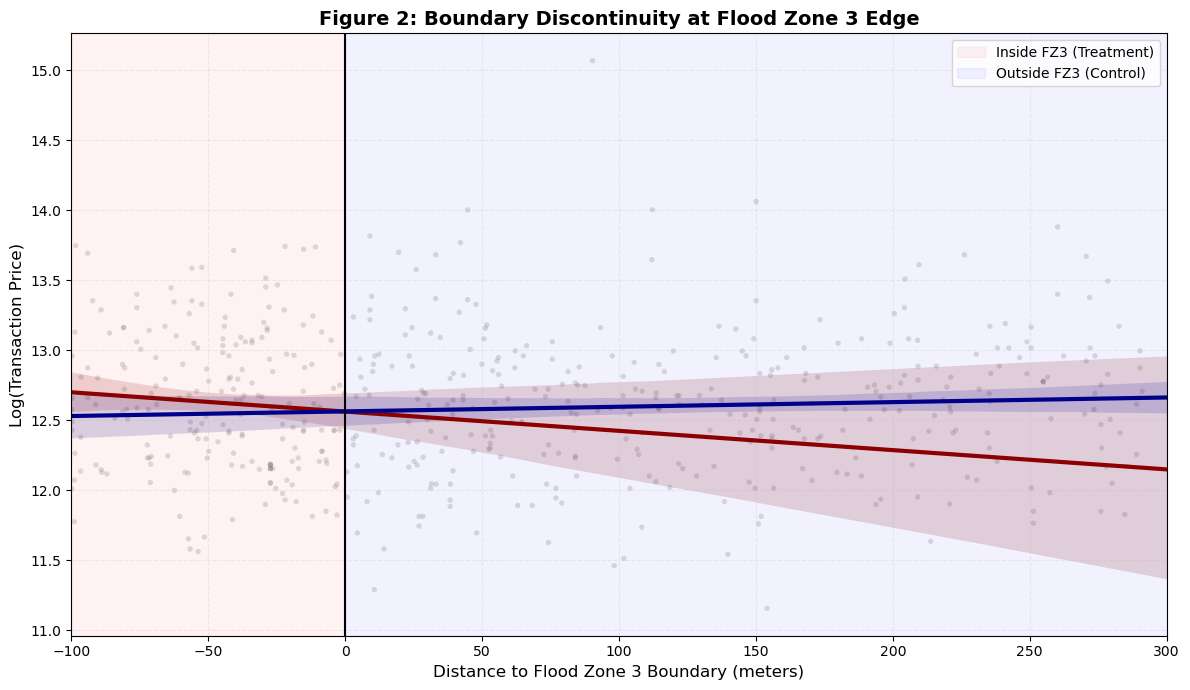

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure log_price exists
matched_bdp['log_price'] = np.log(matched_bdp['Price'])

# Focus on the relevant bandwidth
bandwidth_df = matched_bdp[(matched_bdp['running_var'] >= -100) & 
                           (matched_bdp['running_var'] <= 300)].copy()

plt.figure(figsize=(12, 7))

# 1. Split data for two separate lines
inside = bandwidth_df[bandwidth_df['running_var'] < 0]
outside = bandwidth_df[bandwidth_df['running_var'] >= 0]

# 2. Plot Scatter first - Increase alpha to 0.25 so points are visible
plt.scatter(inside['running_var'], inside['log_price'], s=15, alpha=0.25, color='gray', edgecolors='none')
plt.scatter(outside['running_var'], outside['log_price'], s=15, alpha=0.25, color='gray', edgecolors='none')

# 3. Plot bold regression lines - We use order=1 for a clean linear jump
if not inside.empty:
    sns.regplot(x='running_var', y='log_price', data=inside, 
                scatter=False, color='darkred', truncate=False, 
                line_kws={'lw': 3, 'label': 'Trend: Inside FZ3'})

if not outside.empty:
    sns.regplot(x='running_var', y='log_price', data=outside, 
                scatter=False, color='darkblue', truncate=False, 
                line_kws={'lw': 3, 'label': 'Trend: Outside FZ3'})

# 4. Formatting for Q1 Journal
plt.axvline(x=0, color='black', linestyle='-', lw=1.5) # Hard boundary line
plt.axvspan(-100, 0, color='red', alpha=0.05, label='Inside FZ3 (Treatment)')
plt.axvspan(0, 300, color='blue', alpha=0.05, label='Outside FZ3 (Control)')

plt.xlabel('Distance to Flood Zone 3 Boundary (meters)', fontsize=12)
plt.ylabel('Log(Transaction Price)', fontsize=12)
plt.title('Figure 2: Boundary Discontinuity at Flood Zone 3 Edge', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', frameon=True)
plt.xlim(-100, 300)
plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()

# Save for your report
plt.savefig("Figure2_Boundary_Discontinuity_Reinvented2.png", dpi=300)
plt.show()

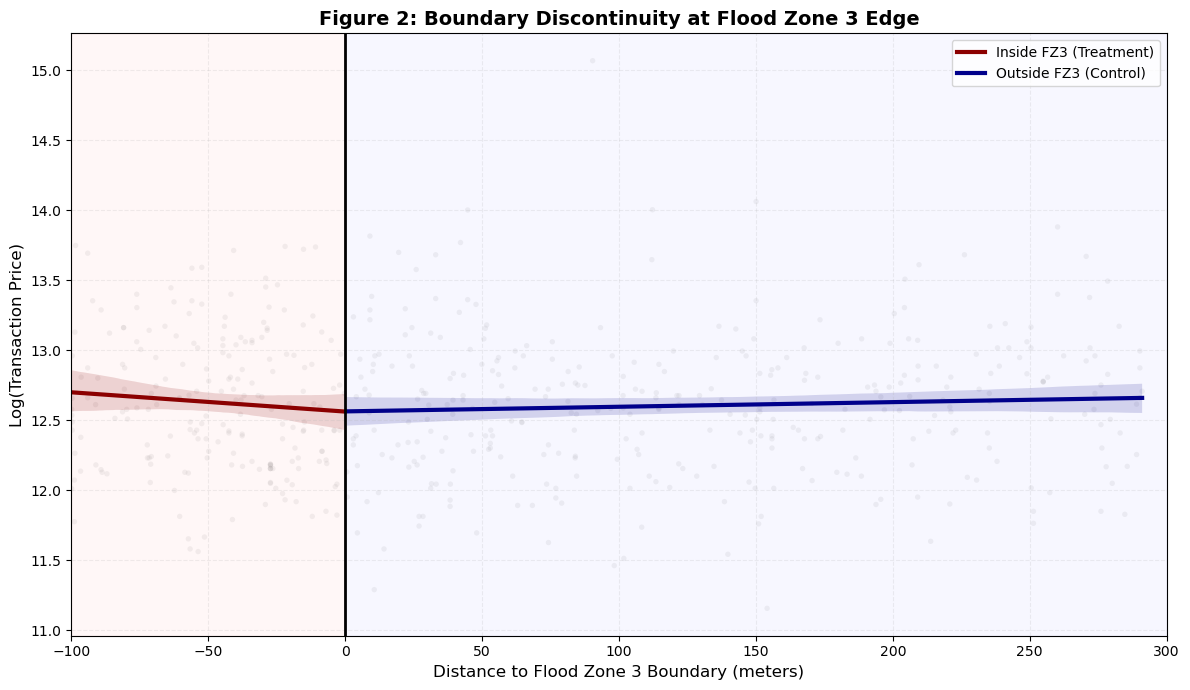

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we use the reinvented running_var and log_price
plt.figure(figsize=(12, 7))

# Split data
inside = bandwidth_df[bandwidth_df['running_var'] < 0]
outside = bandwidth_df[bandwidth_df['running_var'] >= 0]

# 1. Plot Scatter with slightly more 'pop'
plt.scatter(bandwidth_df['running_var'], bandwidth_df['log_price'], 
            s=15, alpha=0.15, color='darkgray', edgecolors='none')

# 2. Plot separate regression lines with Confidence Intervals
sns.regplot(x='running_var', y='log_price', data=inside, 
            scatter=False, color='darkred', label='Inside FZ3 (Treatment)', 
            line_kws={'lw': 3})

sns.regplot(x='running_var', y='log_price', data=outside, 
            scatter=False, color='darkblue', label='Outside FZ3 (Control)', 
            line_kws={'lw': 3})

# 3. Formatting
plt.axvline(x=0, color='black', lw=2, linestyle='-')
plt.axvspan(-100, 0, color='red', alpha=0.03)
plt.axvspan(0, 300, color='blue', alpha=0.03)

plt.xlabel('Distance to Flood Zone 3 Boundary (meters)', fontsize=12)
plt.ylabel('Log(Transaction Price)', fontsize=12)
plt.title('Figure 2: Boundary Discontinuity at Flood Zone 3 Edge', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.xlim(-100, 300)
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()

# Save for your report
plt.savefig("Figure2_Boundary_Discontinuity_Reinvented3.png", dpi=300)
plt.show()

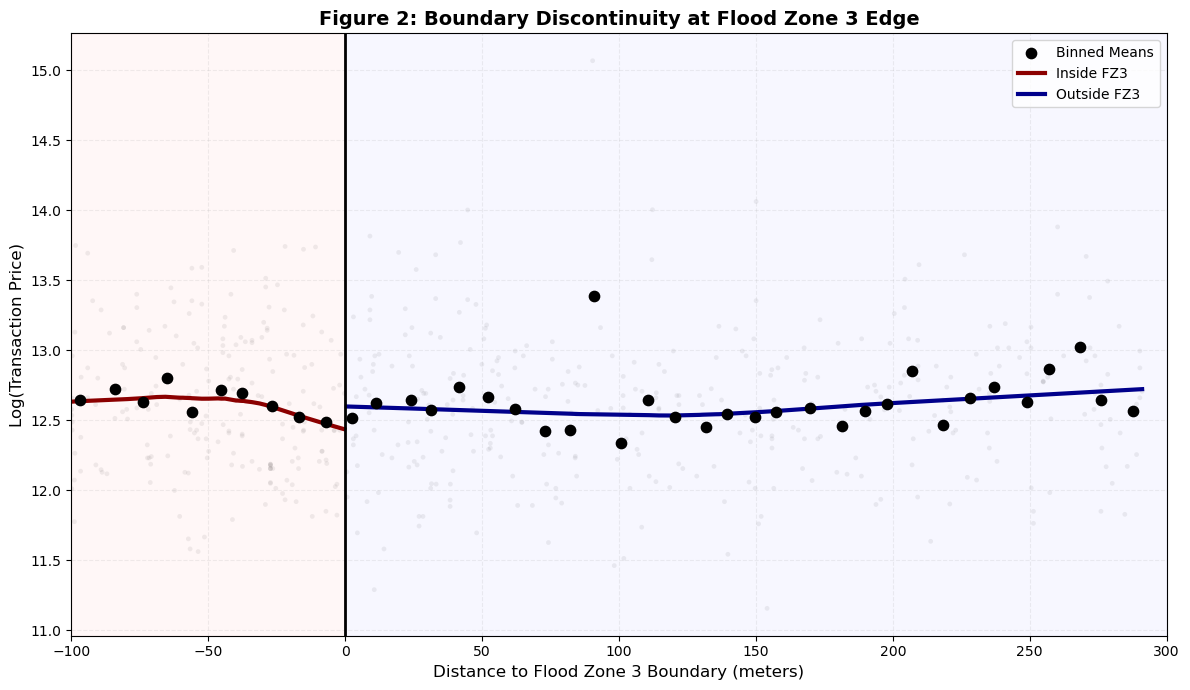

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# PARAMETERS (edit if needed)
# ----------------------------
LEFT_BW  = -100
RIGHT_BW = 300
N_BINS   = 40
OUTFILE  = "Figure2_Boundary_Discontinuity_Q1.png"

# ----------------------------
# BANDWIDTH RESTRICTION
# ----------------------------
bdp = matched_bdp.loc[
    (matched_bdp['running_var'] >= LEFT_BW) &
    (matched_bdp['running_var'] <= RIGHT_BW)
].copy()

inside  = bdp[bdp['running_var'] < 0]
outside = bdp[bdp['running_var'] >= 0]

# ----------------------------
# BINNED MEANS (visual anchor)
# ----------------------------
bdp['bin'] = pd.cut(bdp['running_var'], bins=N_BINS)
binned = (
    bdp.groupby('bin', observed=True)
       .agg(x=('running_var', 'mean'),
            y=('log_price', 'mean'))
       .dropna()
)

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(12, 7))

# Raw scatter (background)
plt.scatter(
    bdp['running_var'], bdp['log_price'],
    s=12, alpha=0.12, color='grey', edgecolors='none'
)

# Binned means
plt.scatter(
    binned['x'], binned['y'],
    s=55, color='black', zorder=5, label='Binned Means'
)

# Local smoothers (LOWESS)
sns.regplot(
    x='running_var', y='log_price', data=inside,
    scatter=False, lowess=True, color='darkred',
    line_kws={'lw': 3}, label='Inside FZ3'
)

sns.regplot(
    x='running_var', y='log_price', data=outside,
    scatter=False, lowess=True, color='darkblue',
    line_kws={'lw': 3}, label='Outside FZ3'
)

# Cutoff and shading
plt.axvline(0, color='black', lw=2)
plt.axvspan(LEFT_BW, 0, color='red', alpha=0.03)
plt.axvspan(0, RIGHT_BW, color='blue', alpha=0.03)

# Labels & styling
plt.xlabel('Distance to Flood Zone 3 Boundary (meters)', fontsize=12)
plt.ylabel('Log(Transaction Price)', fontsize=12)
plt.title('Figure 2: Boundary Discontinuity at Flood Zone 3 Edge',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.2, linestyle='--')
plt.xlim(LEFT_BW, RIGHT_BW)
plt.tight_layout()

# Save
plt.savefig(OUTFILE, dpi=300)
plt.show()


In [21]:
# Create bandwidth_df by slicing your main matched dataset
# This isolates properties within 100m inside and 300m outside the FZ3 boundary
bandwidth_df = matched_bdp[(matched_bdp['running_var'] >= -100) & 
                           (matched_bdp['running_var'] <= 300)].copy()

In [23]:
import pandas as pd
import numpy as np

# 1. Select your target columns
variables_to_summary = [
    'Price', 
    'TOTAL_FLOOR_AREA', 
    'ENVIRONMENT_IMPACT_CURRENT', 
    'NUMBER_HABITABLE_ROOMS'
]

# 2. Force conversion to numeric (fixes the TypeError)
for col in variables_to_summary:
    bandwidth_df[col] = pd.to_numeric(bandwidth_df[col], errors='coerce')

# 3. Handle 'CURRENT_ENERGY_RATING' separately 
# (It's a letter A-G, so we can't 'mean' it unless we map it to numbers)
rating_map = {'A': 95, 'B': 85, 'C': 75, 'D': 65, 'E': 55, 'F': 45, 'G': 35}
bandwidth_df['energy_score'] = bandwidth_df['CURRENT_ENERGY_RATING'].map(rating_map)

# 4. Updated variables list for the table
variables_to_summary = ['Price', 'TOTAL_FLOOR_AREA', 'energy_score', 'NUMBER_HABITABLE_ROOMS']

# 5. Generate the summary statistics
table2 = bandwidth_df.groupby('Zone_Label')[variables_to_summary].agg(['mean', 'std']).T

# 6. Format for your journal report
table2.columns = ['Inside FZ3 (Treatment)', 'Outside FZ3 (Control)']
table2 = table2.round(2)

print(table2)

                             Inside FZ3 (Treatment)  Outside FZ3 (Control)
Price                  mean               344070.69              343471.79
                       std                180543.68              250496.77
TOTAL_FLOOR_AREA       mean                   77.05                  80.40
                       std                    27.38                  32.15
energy_score           mean                   70.20                  68.67
                       std                    11.07                   9.66
NUMBER_HABITABLE_ROOMS mean                    3.66                   3.98
                       std                     1.26                   1.31


In [3]:
analysis_df = pd.read_parquet("analysis_ready_full.parquet")

In [28]:
import pandas as pd

# --------------------------------
# Create flood zone group variable
# --------------------------------
analysis_df['flood_group'] = analysis_df['flood_zone'].fillna('Outside')

analysis_df['flood_group'] = analysis_df['flood_group'].replace({
    'FZ3': 'Flood Zone 3',
    'FZ2': 'Flood Zone 2'
})

# --------------------------------
# Select variables for descriptives
# --------------------------------
desc_vars = [
    'log_price',
    'Price',
    'TOTAL_FLOOR_AREA',
    'PlannedDefenseArea',
    #'running_var'   # distance to FZ3 boundary
]

# --------------------------------
# Descriptive statistics
# --------------------------------
table2 = (
    analysis_df
    .groupby('flood_group')[desc_vars]
    .agg(['mean', 'std', 'min', 'max', 'count'])
)

# Clean column names
table2.columns = ['_'.join(col) for col in table2.columns]

table2


,log_price_mean,log_price_std,log_price_min,log_price_max,log_price_count,TOTAL_FLOOR_AREA_mean,TOTAL_FLOOR_AREA_std,TOTAL_FLOOR_AREA_min,TOTAL_FLOOR_AREA_max,TOTAL_FLOOR_AREA_count,PlannedDefenseArea_mean,PlannedDefenseArea_std,PlannedDefenseArea_min,PlannedDefenseArea_max,PlannedDefenseArea_count
flood_group,,,,,,,,,,,,,,,
Flood Zone 2,12.568973,0.455629,11.445717,13.955273,7137,80.622999,32.149520,18.0,811.43,7137,1.0,0.0,1,1,7137
Flood Zone 3,12.610657,0.483673,11.442503,13.968232,39564,79.127504,31.460550,4.8,1409.00,39564,1.0,0.0,1,1,39564
Outside,12.570631,0.444282,11.445717,13.963931,24881,82.743685,34.717871,4.7,2148.00,24881,1.0,0.0,1,1,24881


In [29]:
analysis_df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'geometry', 'origin'

In [53]:
analysis_df['TENURE'].unique()

['rental (private)', 'owner-occupied', 'NO DATA!', 'unknown', 'rental (social)', NaN, 'Owner-occupied', 'Not defined - use in the case of a new dwelli..., 'Rented (private)', 'Rented (social)']
Categories (9, object): ['NO DATA!', 'Not defined - use in the case of a new dwelli..., 'Owner-occupied', 'Rented (private)', ..., 'owner-occupied', 'rental (private)', 'rental (social)', 'unknown']

In [44]:
def mean_sd_min_max(series):
    return f"{series.mean():,.2f} ({series.std():,.2f}) | {series.min():,.2f}–{series.max():,.2f}"


In [46]:
risk_filters = {
    "High Risk": analysis_df["flood_zone"] == "FZ3",
    "Moderate Risk": analysis_df["flood_zone"] == "FZ2",
    "Others": analysis_df["flood_zone"].isna()
}

In [48]:
continuous_vars = {
    "Transaction Price (£)": "Price",
    "Total Floor Area (sqm)": 'TOTAL_FLOOR_AREA',
    "Number of Habitable Rooms": 'NUMBER_HABITABLE_ROOMS',
    #"Energy Efficiency Score (EPC)": "epc_score"
}

rows = []

for label, var in continuous_vars.items():
    row = {"Variable": label}
    for risk, mask in risk_filters.items():
        s = analysis_df.loc[mask, var].dropna()
        row[risk] = mean_sd_min_max(s) if len(s) > 0 else "NA"
    rows.append(row)


In [51]:
property_types = ["Flat", "House", "Maisonette", "Bungalow"]

for ptype in property_types:
    row = {"Variable": f"– {ptype}"}
    for risk, mask in risk_filters.items():
        row[risk] = analysis_df.loc[
            mask & (analysis_df["PROPERTY_TYPE"] == ptype)
        ].shape[0]
    rows.append(row)


In [54]:
tenures = {
    "Leasehold (L)": "L",
    "Freehold (F)": "F"
}

for label, code in tenures.items():
    row = {"Variable": f"– {label}"}
    for risk, mask in risk_filters.items():
        row[risk] = analysis_df.loc[
            mask & (analysis_df["TENURE"] == code)
        ].shape[0]
    rows.append(row)


In [55]:
row = {"Variable": "Policy Management Units (PMUs)"}
for risk, mask in risk_filters.items():
    row[risk] = analysis_df.loc[mask, "pmu"].nunique()

rows.append(row)

In [56]:
descriptive_table = pd.DataFrame(rows)
descriptive_table


,Variable,High Risk,Moderate Risk,Others
0,Transaction Price (£),"338,492.22 (181,637.47) | 93,200.00–1,165,000.00","319,786.12 (159,432.97) | 93,500.00–1,150,000.00","318,381.38 (152,553.83) | 93,500.00–1,160,000.00"
1,Total Floor Area (sqm),"79.13 (31.46) | 4.80–1,409.00",80.62 (32.15) | 18.00–811.43,"82.74 (34.72) | 4.70–2,148.00"
2,Number of Habitable Rooms,3.92 (1.36) | 1.00–20.00,4.00 (1.41) | 1.00–11.00,4.10 (1.44) | 1.00–72.00
3,– Flat,10286,2198,5575
4,– House,23425,4416,17414
5,– Maisonette,2057,310,1005
6,– Bungalow,3796,213,887
7,– Leasehold (L),0,0,0
8,– Freehold (F),0,0,0
9,Policy Management Units (PMUs),16,14,15


In [57]:
descriptive_table.to_latex("table_descriptive_stats.tex", index=False)
descriptive_table.to_csv("table_descriptive_stats.csv", index=False)

In [59]:
analysis_df['quarter'].head()

0    2014Q1
1    2009Q4
2    2014Q3
3    2015Q2
4    2014Q2
Name: quarter, dtype: period[Q-DEC]

## Model Building

In [4]:
analysis_df['sale_count'] = analysis_df.groupby('property_id')['property_id'].transform('count')
rs_df = analysis_df[analysis_df['sale_count'] >= 2].copy()


In [64]:
rs_df['HighRiskZone'] = (rs_df['flood_zone'] == 'FZ3').astype(int)
rs_df['ModerateRiskZone'] = (rs_df['flood_zone'] == 'FZ2').astype(int)


In [70]:
rs_df['Post2013'] = (rs_df["Date of Transfer"] >= "2013-01-01").astype(int)

In [5]:
analysis_df['Post2013'] = (analysis_df['Date of Transfer'] >= "2013-01-01").astype(int)
analysis_df['HighRiskZone'] = (analysis_df['flood_zone'] == 'FZ3').astype(int)
analysis_df['ModerateRiskZone'] = (analysis_df['flood_zone'] == 'FZ2').astype(int)


In [6]:
analysis_df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'geometry', 'origin'

In [7]:
analysis_df['year_quarter_fe'] = analysis_df['quarter'].astype(str)

In [8]:
analysis_df[['quarter', 'year_quarter_fe']].head()

,quarter,year_quarter_fe
0,2014Q1,2014Q1
1,2009Q4,2009Q4
2,2014Q3,2014Q3
3,2015Q2,2015Q2
4,2014Q2,2014Q2


In [80]:
analysis_df["PROPERTY_TYPE"].unique()

['Flat', 'House', 'Maisonette', 'Bungalow']
Categories (4, object): ['Bungalow', 'Flat', 'House', 'Maisonette']

In [83]:
# Column (1): Baseline hedonic (no FE)
m1 = smf.ols(
    formula="""
    log_price ~ HighRiskZone + ModerateRiskZone
    + TOTAL_FLOOR_AREA + NUMBER_HABITABLE_ROOMS
    + C(PROPERTY_TYPE)
    """,
    data=analysis_df
).fit(cov_type='HC1')


# Column (2): Add PMU fixed effects
m2 = smf.ols(
    formula="""
    log_price ~ HighRiskZone + ModerateRiskZone
    + TOTAL_FLOOR_AREA + NUMBER_HABITABLE_ROOMS
    + C(PROPERTY_TYPE)
    + C(pmu)
    """,
    data=analysis_df
).fit(cov_type='HC1')


# Column (3): Add PMU + year-quarter FE
m3 = smf.ols(
    formula="""
    log_price ~ HighRiskZone + ModerateRiskZone
    + TOTAL_FLOOR_AREA + NUMBER_HABITABLE_ROOMS
    + C(PROPERTY_TYPE)
    + C(pmu) + C(year_quarter_fe)
    """,
    data=analysis_df
).fit(cov_type='HC1')


# Column (4): Policy interaction (core specification)
m4 = smf.ols(
    formula="""
    log_price ~ HighRiskZone * Post2013
    + ModerateRiskZone * Post2013
    + TOTAL_FLOOR_AREA + NUMBER_HABITABLE_ROOMS
    + C(PROPERTY_TYPE)
    + C(pmu) + C(year_quarter_fe)
    """,
    data=analysis_df
).fit(cov_type='HC1')


In [84]:
pip install stargazer

In [85]:
from stargazer.stargazer import Stargazer

stargazer = Stargazer([m1, m2, m3, m4])

stargazer.title("Table 3: Hedonic Regression Estimates of Flood Risk")
stargazer.custom_columns(
    ['(1) Baseline', '(2) + PMU FE', '(3) + PMU & Time FE', '(4) Policy Interaction'],
    [1, 1, 1, 1]
)

stargazer.dependent_variable_name("Log(Transaction Price)")

stargazer.covariate_order([
    'HighRiskZone',
    'ModerateRiskZone',
    'HighRiskZone:Post2013',
    'ModerateRiskZone:Post2013',
    'TOTAL_FLOOR_AREA',
    'NUMBER_HABITABLE_ROOMS'
])

stargazer.show_confidence_intervals(False)
stargazer.show_degrees_of_freedom(False)

stargazer.add_line("PMU Fixed Effects", ["No", "Yes", "Yes", "Yes"])
stargazer.add_line("Year–Quarter Fixed Effects", ["No", "No", "Yes", "Yes"])
stargazer.add_line("Robust SEs", ["Yes", "Yes", "Yes", "Yes"])

# Export
with open("Table3_Hedonic_Regression.html", "w") as f:
    f.write(stargazer.render_html())


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 91, but rank is 90
  warnings.warn('covariance of constraints does not have full '


In [12]:
analysis_df["year_quarter_fe"].head()

0    2014Q1
1    2009Q4
2    2014Q3
3    2015Q2
4    2014Q2
Name: year_quarter_fe, dtype: object

In [10]:
analysis_df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'geometry', 'origin'

In [17]:
#import statsmodels.formula.api as smf

qr_formula = """
log_price ~ HighRiskZone + ModerateRiskZone
+ TOTAL_FLOOR_AREA
+ NUMBER_HABITABLE_ROOMS
+ C(PROPERTY_TYPE)
+ C(year_quarter_fe)
"""


In [18]:
quantiles = [0.25, 0.50, 0.75]

qr_models = {}

for q in quantiles:
    model = smf.quantreg(
        qr_formula,
        data=analysis_df
    ).fit(q=q)
    
    qr_models[q] = model

In [19]:
from statsmodels.iolib.summary2 import summary_col

qr_table = summary_col(
    results=[qr_models[0.25], qr_models[0.50], qr_models[0.75]],
    stars=True,
    float_format="%.3f",
    model_names=["Q25", "Q50 (Median)", "Q75"],
    info_dict={
        "Observations": lambda x: f"{int(x.nobs)}",
        "Year-Quarter FE": lambda x: "Yes",
        "Property Type FE": lambda x: "Yes"
    }
)

print(qr_table)


                                  Q25    Q50 (Median)    Q75   
---------------------------------------------------------------
Intercept                      11.462*** 11.412***    11.343***
                               (0.043)   (0.044)      (0.061)  
C(PROPERTY_TYPE)[T.Flat]       -0.143*** 0.066***     0.274*** 
                               (0.005)   (0.005)      (0.008)  
C(PROPERTY_TYPE)[T.House]      0.049***  0.123***     0.187*** 
                               (0.005)   (0.005)      (0.007)  
C(PROPERTY_TYPE)[T.Maisonette] -0.026*** 0.163***     0.289*** 
                               (0.007)   (0.008)      (0.011)  
C(year_quarter_fe)[T.2009Q1]   -0.112**  -0.110**     -0.093   
                               (0.051)   (0.052)      (0.072)  
C(year_quarter_fe)[T.2009Q2]   -0.078*   -0.078*      -0.036   
                               (0.046)   (0.047)      (0.066)  
C(year_quarter_fe)[T.2009Q3]   -0.001    0.008        0.066    
                               (0.045) 

In [25]:
import pandas as pd

def extract_qr_results(results_dict):
    """
    results_dict = {0.25: res25, 0.50: res50, 0.75: res75}
    """
    rows = []

    for q, res in results_dict.items():
        for var in res.params.index:
            rows.append({
                "Variable": var,
                "Quantile": f"Q{int(q*100)}",
                "Coefficient": res.params[var],
                "Std_Error": res.bse[var],
                "P_value": res.pvalues[var]
            })

    return pd.DataFrame(rows)


In [27]:
formula = """
log_price ~ HighRiskZone + ModerateRiskZone
+ TOTAL_FLOOR_AREA + NUMBER_HABITABLE_ROOMS
+ C(PROPERTY_TYPE) + C(year_quarter_fe)
"""

# Fit quantile regressions
qr_25 = smf.quantreg(formula, analysis_df).fit(q=0.25)
qr_50 = smf.quantreg(formula, analysis_df).fit(q=0.50)
qr_75 = smf.quantreg(formula, analysis_df).fit(q=0.75)

In [28]:
qr_results = {
    0.25: qr_25,
    0.50: qr_50,
    0.75: qr_75
}

qr_long = extract_qr_results(qr_results)


In [29]:
qr_table = qr_long.pivot(
    index="Variable",
    columns="Quantile",
    values=["Coefficient", "Std_Error"]
)

qr_table.columns = [
    f"{stat}_{q}" for stat, q in qr_table.columns
]


In [30]:
qr_table.to_csv("Table4_Quantile_Regression.csv")


In [31]:
import pandas as pd

def coef_se(model):
    return model.params, model.bse

params_25, se_25 = coef_se(qr_25)
params_50, se_50 = coef_se(qr_50)
params_75, se_75 = coef_se(qr_75)

# Union of all variable names
variables = sorted(
    set(params_25.index) | set(params_50.index) | set(params_75.index)
)

table = pd.DataFrame(index=variables)

table["Q25"] = [
    f"{params_25.get(v, float('nan')):.3f} ({se_25.get(v, float('nan')):.3f})"
    for v in variables
]

table["Q50 (Median)"] = [
    f"{params_50.get(v, float('nan')):.3f} ({se_50.get(v, float('nan')):.3f})"
    for v in variables
]

table["Q75"] = [
    f"{params_75.get(v, float('nan')):.3f} ({se_75.get(v, float('nan')):.3f})"
    for v in variables
]


In [32]:
table.loc["Observations"] = [
    f"{int(qr_25.nobs)}",
    f"{int(qr_50.nobs)}",
    f"{int(qr_75.nobs)}"
]

table.loc["Property Type FE"] = ["Yes", "Yes", "Yes"]
table.loc["Year–Quarter FE"] = ["Yes", "Yes", "Yes"]


In [33]:
table.to_csv("Table4_Quantile_Regression_Q1.csv")

In [20]:
rdd_df = analysis_df.copy()


In [21]:
gdb_path = "Flood-Map-For-Planning-Flood-Zones.gdb/FMfP_Flood_Zones_v202503.gdb"
fiona.listlayers(gdb_path)

['Flood_Zones_2_3_Rivers_and_Sea']

In [22]:
#Load Flood Zone layer and simplify ===
flood_zones = gpd.read_file(gdb_path, layer='Flood_Zones_2_3_Rivers_and_Sea')
flood_zones = flood_zones.to_crs('EPSG:27700')  # Match EPC CRS 

C:\Users\HP\anaconda3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


In [37]:
print("Hello World!!!")

Hello World!!!


In [38]:
def run_rdd(df, bw):
    sub = df[df['running_var'].abs() <= bw]
    model = smf.ols(
        "log_price ~ HighRiskZone + ModerateRiskZone + TOTAL_FLOOR_AREA + "
        "NUMBER_HABITABLE_ROOMS + C(PROPERTY_TYPE) + C(year_quarter_fe)",
        data=sub
    ).fit(cov_type="HC1")
    return model


In [39]:
bandwidths = [50, 100, 200, 500]
models = {bw: run_rdd(rdd_df, bw) for bw in bandwidths}


KeyError: 'running_var'

In [40]:
rdd_df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'geometry', 'origin'

In [43]:
fz3_dissolved = fz3_gdf.dissolve()
fz3_boundary = fz3_dissolved.geometry.iloc[0].boundary

# 3. Compute distance to nearest FZ3 boundary
rdd_df['running_var'] = rdd_df.geometry.apply(
    lambda x: fz3_boundary.distance(x).min()
)

# 4. Assign sign: inside FZ3 = negative
rdd_df.loc[rdd_df['flood_zone'] == 'FZ3', 'running_var'] *= -1

GEOSException: bad allocation

In [ ]:
bandwidths = [50, 100, 200, 500]

rdd_samples = {
    bw: rdd_df[rdd_df['running_var'].abs() <= bw].copy()
    for bw in bandwidths
}


In [ ]:
import statsmodels.formula.api as smf

models = {}

for bw, df_bw in rdd_samples.items():
    models[bw] = smf.ols(
        formula="""
        log_price ~ 
        HighRiskZone 
        + running_var
        + TOTAL_FLOOR_AREA
        + NUMBER_HABITABLE_ROOMS
        + C(PROPERTY_TYPE)
        + C(year_quarter_fe)
        """,
        data=df_bw
    ).fit(cov_type="HC1")


In [ ]:
from stargazer.stargazer import Stargazer

stargazer = Stargazer([models[bw] for bw in bandwidths])
stargazer.title("Table 5. Boundary Discontinuity Estimates at Flood Zone 3 Edge")
stargazer.custom_columns(
    ['50 m', '100 m', '200 m', '500 m'], 
    [1, 1, 1, 1]
)

stargazer.covariate_order([
    'HighRiskZone',
    'running_var',
    'TOTAL_FLOOR_AREA',
    'NUMBER_HABITABLE_ROOMS'
])

stargazer.add_line(
    'Bandwidth (m)', 
    bandwidths
)

stargazer.add_line(
    'Property Type FE', 
    ['Yes'] * 4
)

stargazer.add_line(
    'Year-Quarter FE', 
    ['Yes'] * 4
)

stargazer.add_line(
    'Observations',
    [int(models[bw].nobs) for bw in bandwidths]
)

print(stargazer.render_latex())


In [47]:
analysis_df['event_time'].head()

0    1
1   -4
2    1
3    2
4    1
Name: event_time, dtype: int32

In [45]:
# Ensure year is numeric
analysis_df['year'] = analysis_df['year'].astype(int)

# TE2100 baseline year
TE2100_YEAR = 2013

# Event time (leads/lags)
analysis_df['event_time'] = analysis_df['year'] - TE2100_YEAR


In [46]:
analysis_df = analysis_df[
    (analysis_df['event_time'] >= -6) &
    (analysis_df['event_time'] <= 8)
]


In [48]:
event_dummies = [
    f"ET_{k}" for k in range(-6, 9) if k != -1
]

for k in range(-6, 9):
    if k != -1:
        analysis_df[f'ET_{k}'] = (
            (analysis_df['event_time'] == k) &
            (analysis_df['PlannedDefenseArea'] == 1)
        ).astype(int)


C:\Users\HP\AppData\Local\Temp\ipykernel_10348\4145869971.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df[f'ET_{k}'] = (
C:\Users\HP\AppData\Local\Temp\ipykernel_10348\4145869971.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df[f'ET_{k}'] = (
C:\Users\HP\AppData\Local\Temp\ipykernel_10348\4145869971.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

In [50]:
import statsmodels.formula.api as smf

event_terms = " + ".join(event_dummies)

formula = f"""
log_price ~ {event_terms}
+ TOTAL_FLOOR_AREA
+ NUMBER_HABITABLE_ROOMS
+ C(PROPERTY_TYPE)
+ C(year)
+ C(property_id)
"""

event_model = smf.ols(
    formula=formula,
    data=analysis_df
).fit(
    cov_type='cluster',
    cov_kwds={'groups': analysis_df['property_id']}
)


PatsyError: numbers besides '0' and '1' are only allowed with **
    log_price ~ ET_-6 + ET_-5 + ET_-4 + ET_-3 + ET_-2 + ET_0 + ET_1 + ET_2 + ET_3 + ET_4 + ET_5 + ET_6 + ET_7 + ET_8 + TOTAL_FLOOR_AREA + NUMBER_HABITABLE_ROOMS + C(PROPERTY_TYPE) + C(year) + C(property_id)
                    ^